# video 처럼 다루어 보자

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import tifffile as tiff
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision import transforms
from sklearn.model_selection import train_test_split
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import torch.optim as optim
import rasterio
import copy
import torch.nn.init as init

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### train, eval 함수 정의 (Naive ver과 동일)

In [3]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50, patience=10):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = model.state_dict()  # 초기 모델 가중치 저장
    no_improve_count = 0

    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)  # 배치별 loss * 개수로 전체 손실 계산
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)  # 전체 샘플 수로 나눔
        train_accuracy = 100 * correct / total
        train_losses.append(train_loss)

        # Validation Phase
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * labels.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_loss)

        print(f"\nEpoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%\n")

        # Early Stopping & Model Saving
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            print("Early stopping triggered. Training stopped.")
            break
    
    return best_model_state, train_losses, val_losses


In [4]:
target_name_mapping = {
    0: "Non-Forest", #비산림
    1: "Pine", #소나무
    2: "Nut Pine", #잣나무
    3: "Larch", #낙엽송
    4: "Pitch Pine", #리기다 소나무
    5: "Oak", #상수리나무
    6: "Mongolian Oak", #신갈나무
    7: "Oriental Oak" #굴참나무
}

def evaluate_model_with_cm(model, val_loader, num_classes=8, target_name_mapping=target_name_mapping):
    model.eval()
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluation Progress"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())  
            all_predictions.extend(predicted.cpu().numpy())  

    # 모든 클래스 목록 (0 ~ num_classes-1)
    full_class_labels = np.arange(num_classes)

    # Confusion Matrix 계산
    cm = confusion_matrix(all_labels, all_predictions, labels=full_class_labels)

    # Confusion Matrix 시각화
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_name_mapping.values(), yticklabels=target_name_mapping.values())
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()
    
    # Classification Report
    target_names = list(target_name_mapping.values())
    report = classification_report(all_labels, all_predictions, labels=full_class_labels, target_names=target_names, digits=3)

    print("Classification Report:")
    print(report)


### Dataset 클래스 정의 (Naive ver과 동일)

In [5]:
class TiffDataset(Dataset):
    def __init__(self, large_tif_dir, file_list, label_file, patch_size=3, box_filter_fn=None, transform=None):
        """
        Args:
            large_tif_dir (str): 여러 개의 큰 TIFF 파일이 저장된 디렉토리 경로.
            file_list (list of str): 처리할 원천 데이터 파일명 리스트.
            label_file (str): 라벨 정보를 담은 CSV 파일 경로 ("file", "x_pos", "y_pos", "label" 열 포함).
            patch_size (int): 슬라이싱할 이미지의 크기 (기본값: 3).
            box_filter_fn (callable, optional): 박스 번호 필터링 함수. 
                - 입력: 박스 번호 (1부터 100까지)
                - 출력: 해당 박스를 사용할지 여부 (True/False).
                - 기본값: None (모든 박스 사용).
            transform (callable, optional): 이미지 전처리에 사용할 함수.
        """
        self.large_tif_dir = large_tif_dir
        self.file_list = set(file_list)
        self.label_df = pd.read_csv(label_file)

        # 박스 필터 함수 설정 (기본값: 모든 박스 사용)
        self.box_filter_fn = box_filter_fn or (lambda box_number: True)

        # 파일명 필터링: file_list에 있는 파일만 유지
        self.label_df = self.label_df[self.label_df['file'].isin(self.file_list)].reset_index(drop=True)

        # 박스 번호 필터링
        self.label_df = self.label_df[self.label_df['box_number'].apply(self.box_filter_fn)].reset_index(drop=True)

        self.patch_size = patch_size
        self.transform = transform

        # 각 파일명을 키로 하고 이미지를 값으로 가지는 딕셔너리
        self.image_cache = {}

    def _load_image(self, file_name):
        """파일 이름에 해당하는 이미지를 로드하여 캐시에 저장."""
        if file_name not in self.image_cache:
            file_path = os.path.join(self.large_tif_dir, file_name)
            if not os.path.exists(file_path):
                raise FileNotFoundError(f"Image file '{file_path}' not found.")
            self.image_cache[file_name] = tiff.imread(file_path)
        return self.image_cache[file_name]

    def __len__(self):
        return len(self.label_df)

    def __getitem__(self, idx):
        # 현재 인덱스에 해당하는 데이터 가져오기
        row = self.label_df.iloc[idx]
        file_name = row["file"]
        x, y = row["x_pos"], row["y_pos"]
        label = row["label"]

        # 이미지 로드
        image = self._load_image(file_name)
        image_height, image_width = image.shape[:2]

        # 범위 검사
        if x < 0 or y < 0 or x + self.patch_size > image_width or y + self.patch_size > image_height:
            raise ValueError(f"Patch at position (x={x}, y={y}) exceeds bounds of image '{file_name}'.")

        # 이미지 슬라이싱
        patch = image[y:y + self.patch_size, x:x + self.patch_size]
        # 전처리 적용
        if self.transform:
            patch = self.transform(patch)

        return patch, label


### 테스트지역 선별 (Naive ver과 동의)

In [6]:
# 테스트 필터 정의
test_filter = lambda box_number: (box_number % 9 == 0 or box_number % 9 == 5)

### 데이터 전처리 방법 설정

In [132]:
class ReshapeTransform:
    """(12*bands, 3, 3) → (12, bands, 3, 3) 변환"""
    def __init__(self, bands):
        self.bands = bands

    def __call__(self, x):
        return x.view(12, self.bands, 3, 3).permute(1, 0, 2, 3)

def get_transform(bands, scale_channels_func=None):
    transform_list = [
        transforms.ToTensor(),  # (H, W, C) → (C, H, W)
        transforms.Lambda(lambda x: x.float()),  # uint16 → float 변환
        ReshapeTransform(bands)  # (12*bands, 3, 3) → (bands, 12, 3, 3)
    ]

    if scale_channels_func:
        transform_list.append(transforms.Lambda(scale_channels_func))  # 채널별 값 조정 추가

    return transforms.Compose(transform_list)

#scaling 함수 - 채널별로 범위의 차이가 크기때문에 어느정도 맞추어주기 위해서 수행
def scale_channels(x):
    """특정 채널값 조정"""
    x[0:3] *= 5  # B,G,R 채널 * 5
    if 4 < x.shape[0]:
        x[4] *= 0.5  # NDVI 채널 * 0.5
    return x

### 2 + 1 CNN이용한 단순한 resnet 모델

In [111]:
# SwigLU 활성 함수 정의 (SiLU 변형)
class SwigLU(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(1.3 * x)

# 2+1D 컨볼루션 블록: 공간과 시간 축을 분리하여 컨볼루션 수행
class Conv2Plus1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(3,3,3), stride=1, padding=1):
        super().__init__()
        mid_channels = out_channels  # 중간 채널 수 설정
        
        # 공간 차원에 대한 2D 컨볼루션
        self.spatial_conv = nn.Conv3d(in_channels, mid_channels, kernel_size=(1, kernel_size[1], kernel_size[2]), 
                                      stride=(1, stride, stride), padding=(0, padding, padding), bias=False)
        self.bn1 = nn.BatchNorm3d(mid_channels)
        
        # 시간 차원에 대한 1D 컨볼루션
        self.temporal_conv = nn.Conv3d(mid_channels, out_channels, kernel_size=(kernel_size[0], 1, 1), 
                                       stride=(stride, 1, 1), padding=(padding, 0, 0), bias=False)
        self.bn2 = nn.BatchNorm3d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):
        x = self.relu(self.bn1(self.spatial_conv(x)))
        x = self.relu(self.bn2(self.temporal_conv(x)))
        return x

# ResNet 스타일의 기본 블록 (Skip Connection 포함)
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = Conv2Plus1D(channels, channels)
        self.conv2 = Conv2Plus1D(channels, channels)
        self.bn = nn.BatchNorm3d(channels)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        residual = x  # 원본 입력 저장
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn(x)
        return self.relu(x + residual)  # Skip Connection 적용

# 밴드(채널) 확장 블록: 1x1 컨볼루션 사용
class BandExpansion(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm3d(out_channels)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

# 피드포워드 블록: SwigLU 활성 함수와 확장 비율 적용
class FeedForward(nn.Module):
    def __init__(self, channels, expand_ratio=2):
        super().__init__()
        hidden_dim = channels * expand_ratio  # 확장된 채널 크기
        self.fc1 = nn.Conv3d(channels, hidden_dim, kernel_size=1)
        self.act = SwigLU()
        self.fc2 = nn.Conv3d(hidden_dim, channels, kernel_size=1)
        self.bn = nn.BatchNorm3d(channels)
    
    def forward(self, x):
        return self.bn(self.fc2(self.act(self.fc1(x))))

# 전체 비디오 분류 모델
class VideoClassifier(nn.Module):
    def __init__(self, input_bands, stage_repeats, stage_channels, num_classes=8):
        super().__init__()
        
        # 초기 밴드 확장 (입력 밴드 수 -> 첫 번째 stage 채널 크기)
        self.initial_conv = BandExpansion(input_bands, stage_channels[0])
        
        self.stages = nn.ModuleList()
        in_channels = stage_channels[0]
        
        # 4개의 Stage 구성
        for stage_idx in range(4):
            # 기본 ResBlock 반복 적용
            blocks = [ResBlock(in_channels) for _ in range(stage_repeats[stage_idx])]
            self.stages.append(nn.Sequential(*blocks))
            
            # 마지막 Stage를 제외하고 밴드 확장 수행
            if stage_idx < 3:
                self.stages.append(BandExpansion(in_channels, stage_channels[stage_idx + 1]))
                in_channels = stage_channels[stage_idx + 1]
        
        # 글로벌 평균 풀링 적용 (공간 차원 제거)
        self.gap = nn.AdaptiveAvgPool3d(1)
        
        # 피드포워드 블록 2개 추가
        self.ff1 = FeedForward(in_channels)
        self.ff2 = FeedForward(in_channels)
        
        # 최종 분류기 (Linear 레이어)
        self.classifier = nn.Linear(in_channels, num_classes)
        
    def forward(self, x):
        x = self.initial_conv(x)  # 초기 밴드 확장 적용
        
        # Stage 반복 수행
        for stage in self.stages:
            x = stage(x)
        
        # 글로벌 평균 풀링 적용 후 차원 축소
        x = self.gap(x).view(x.size(0), -1)
        
        # 피드포워드 블록 두 개 통과
        x = self.ff1(x.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1))
        x = self.ff2(x)
        
        # 최종 분류기 적용
        x = self.classifier(x.squeeze(-1).squeeze(-1).squeeze(-1))
        return x


### He 초기화 사용

In [112]:
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Conv3d):
        init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')  # He 초기화 적용
        if m.bias is not None:
            init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')  # 선형 레이어에도 Kaiming 초기화 적용
        if m.bias is not None:
            init.zeros_(m.bias)


## B, G, R, NIR 사용

In [114]:
large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\naive" #원천데이터 주소
bands = 4 #밴드 수

transform = get_transform(bands, scale_channels)

train_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [ ]:
input_channels = 4  # Number of input bands
stage_repeats = [2, 3, 5, 2]  # Stage 3이 가장 깊음
stage_channels = [8, 16, 32, 48]  # 점진적으로 증가
model = VideoClassifier(input_channels, stage_repeats, stage_channels, num_classes=8)

model.apply(init_weights)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 모델 학습

In [ ]:
best_model_state, train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, patience=100)
model.load_state_dict(best_model_state)
torch.save(best_model_state, "./video2_30.pth")

### 모델 테스트

train data

Evaluation Progress: 100%|██████████| 3733/3733 [01:24<00:00, 44.18it/s]


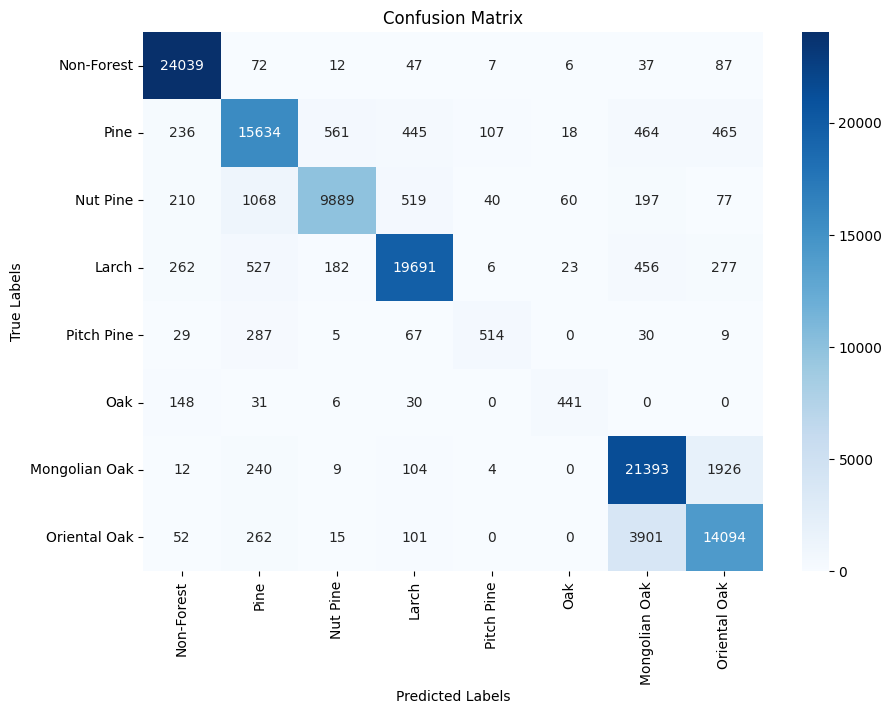

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.962     0.989     0.975     24307
         Pine      0.863     0.872     0.867     17930
     Nut Pine      0.926     0.820     0.870     12060
        Larch      0.937     0.919     0.928     21424
   Pitch Pine      0.758     0.546     0.635       941
          Oak      0.805     0.672     0.733       656
Mongolian Oak      0.808     0.903     0.853     23688
 Oriental Oak      0.832     0.765     0.797     18425

     accuracy                          0.885    119431
    macro avg      0.861     0.811     0.832    119431
 weighted avg      0.886     0.885     0.884    119431



In [13]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

validation data

Evaluation Progress: 100%|██████████| 1169/1169 [00:25<00:00, 45.02it/s]


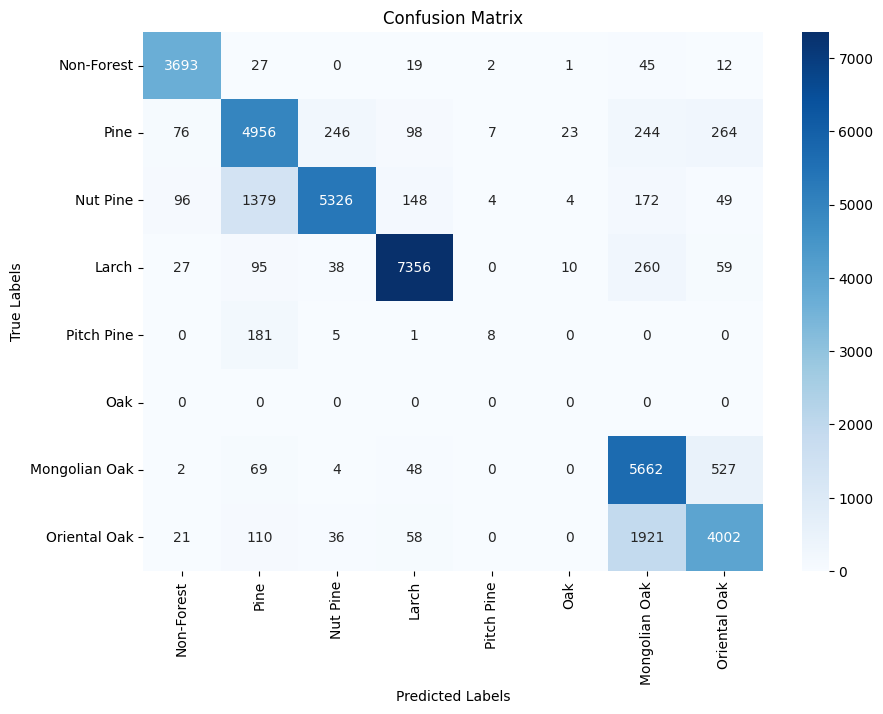

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.943     0.972     0.957      3799
         Pine      0.727     0.838     0.779      5914
     Nut Pine      0.942     0.742     0.830      7178
        Larch      0.952     0.938     0.945      7845
   Pitch Pine      0.381     0.041     0.074       195
          Oak      0.000     0.000     0.000         0
Mongolian Oak      0.682     0.897     0.775      6312
 Oriental Oak      0.815     0.651     0.724      6148

     accuracy                          0.829     37391
    macro avg      0.680     0.635     0.635     37391
 weighted avg      0.842     0.829     0.828     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
evaluate_model_with_cm(model, val_loader, num_classes=8)

## NDVI 추가

In [15]:
large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\with_ndvi" #원천데이터 주소
bands = 5 #밴드 수

transform = get_transform(bands, scale_channels)

train_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [16]:
input_channels = 5  # Number of input bands
stage_repeats = [3, 4, 7, 3]  
stage_channels = [12, 24, 48, 64]
model = VideoClassifier(input_channels, stage_repeats, stage_channels, num_classes=8)

model.apply(init_weights)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 모델 학습

In [ ]:
best_model_state, train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15, patience=100)
model.load_state_dict(best_model_state)
torch.save(best_model_state, "./video2_with_ndvi_15.pth")

### 모델 테스트

train data

Evaluation Progress: 100%|██████████| 3733/3733 [01:36<00:00, 38.64it/s]


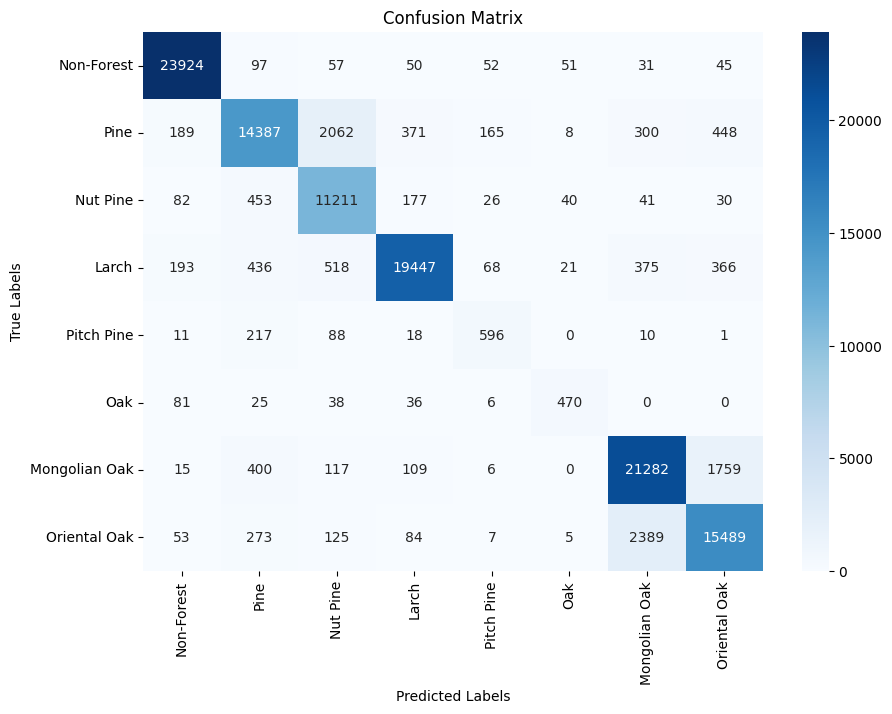

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.975     0.984     0.979     24307
         Pine      0.883     0.802     0.841     17930
     Nut Pine      0.789     0.930     0.853     12060
        Larch      0.958     0.908     0.932     21424
   Pitch Pine      0.644     0.633     0.638       941
          Oak      0.790     0.716     0.751       656
Mongolian Oak      0.871     0.898     0.885     23688
 Oriental Oak      0.854     0.841     0.847     18425

     accuracy                          0.894    119431
    macro avg      0.845     0.839     0.841    119431
 weighted avg      0.896     0.894     0.894    119431



In [18]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

validation data

Evaluation Progress: 100%|██████████| 1169/1169 [00:29<00:00, 38.99it/s]


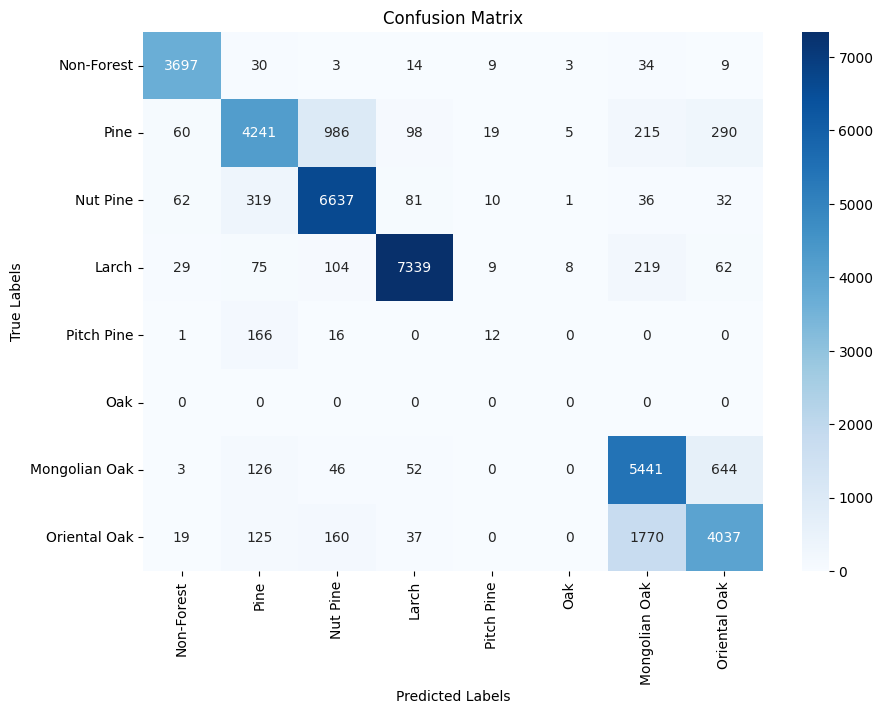

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.955     0.973     0.964      3799
         Pine      0.835     0.717     0.771      5914
     Nut Pine      0.835     0.925     0.877      7178
        Larch      0.963     0.936     0.949      7845
   Pitch Pine      0.203     0.062     0.094       195
          Oak      0.000     0.000     0.000         0
Mongolian Oak      0.705     0.862     0.776      6312
 Oriental Oak      0.796     0.657     0.719      6148

     accuracy                          0.840     37391
    macro avg      0.661     0.641     0.644     37391
 weighted avg      0.842     0.840     0.837     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
evaluate_model_with_cm(model, val_loader, num_classes=8)

## NDVI, Sentinel_2(B05, B06, B07, B11, B12) 데이터 추가

In [118]:
large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\with_ndvi_s2" #원천데이터 주소
bands = 10 #밴드 수

transform = get_transform(bands, scale_channels)

train_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [ ]:
input_channels = 10 
stage_repeats = [4, 6, 10, 4]  
stage_channels = [16, 32, 64, 96]
model = VideoClassifier(input_channels, stage_repeats, stage_channels, num_classes=8)

model.apply(init_weights)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

VideoClassifier(
  (initial_conv): BandExpansion(
    (conv): Conv3d(10, 16, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
    (bn): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
  )
  (stages): ModuleList(
    (0): Sequential(
      (0): ResBlock(
        (conv1): Conv2Plus1D(
          (spatial_conv): Conv3d(16, 16, kernel_size=(1, 3, 3), stride=(1, 1, 1), padding=(0, 1, 1), bias=False)
          (bn1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (temporal_conv): Conv3d(16, 16, kernel_size=(3, 1, 1), stride=(1, 1, 1), padding=(1, 0, 0), bias=False)
          (bn2): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
        )
        (conv2): Conv2Plus1D(
          (spatial_conv): Conv3d(16, 16, kernel_size=(1, 3, 3), stride=(1, 1, 1), padding=(0, 1, 1), bias=False)
          (bn1): BatchNorm3d(16, eps=1

### 모델 학습

In [ ]:
best_model_state, train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15, patience=100)
model.load_state_dict(best_model_state)
torch.save(best_model_state, "./video2_with_ndvi_s2_15.pth")

### 모델 테스트

train data

Evaluation Progress: 100%|██████████| 3733/3733 [02:32<00:00, 24.52it/s]


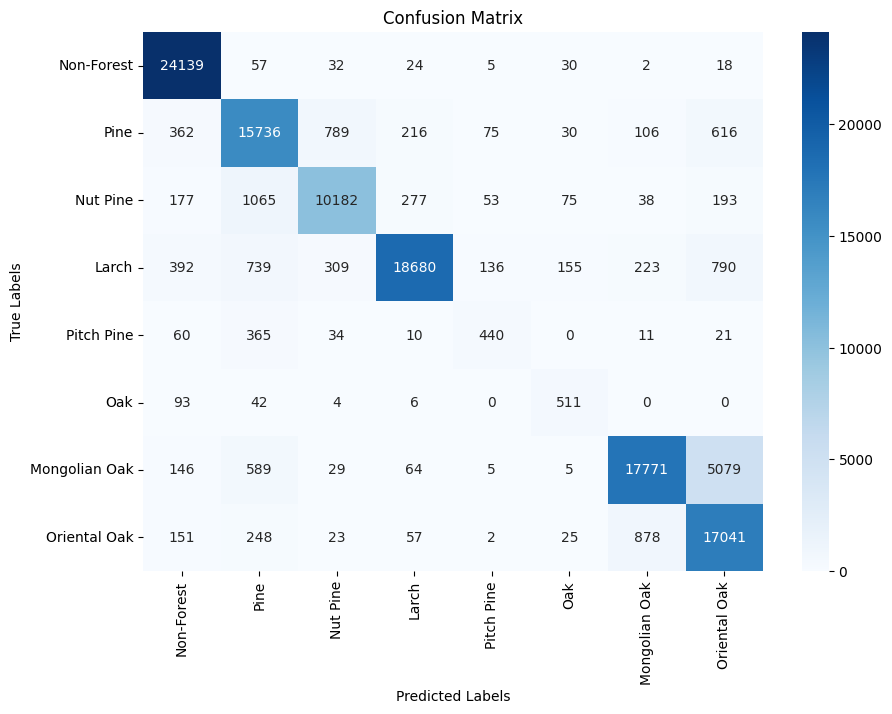

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.946     0.993     0.969     24307
         Pine      0.835     0.878     0.856     17930
     Nut Pine      0.893     0.844     0.868     12060
        Larch      0.966     0.872     0.917     21424
   Pitch Pine      0.615     0.468     0.531       941
          Oak      0.615     0.779     0.687       656
Mongolian Oak      0.934     0.750     0.832     23688
 Oriental Oak      0.717     0.925     0.808     18425

     accuracy                          0.875    119431
    macro avg      0.815     0.814     0.808    119431
 weighted avg      0.885     0.875     0.875    119431



In [23]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

val data

Evaluation Progress: 100%|██████████| 1169/1169 [00:47<00:00, 24.53it/s]


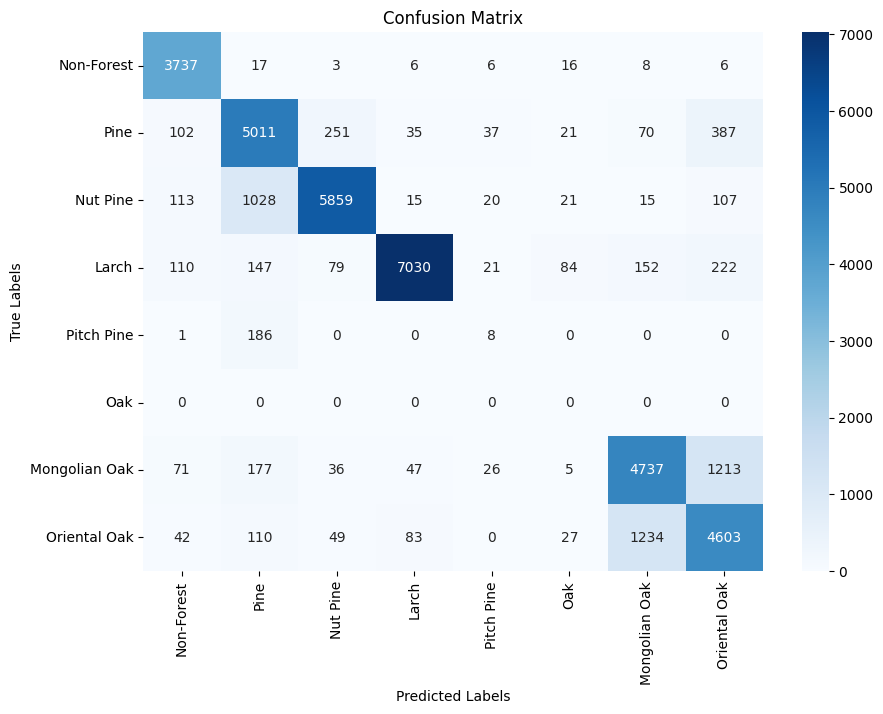

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.895     0.984     0.937      3799
         Pine      0.751     0.847     0.796      5914
     Nut Pine      0.933     0.816     0.871      7178
        Larch      0.974     0.896     0.934      7845
   Pitch Pine      0.068     0.041     0.051       195
          Oak      0.000     0.000     0.000         0
Mongolian Oak      0.762     0.750     0.756      6312
 Oriental Oak      0.704     0.749     0.726      6148

     accuracy                          0.829     37391
    macro avg      0.636     0.635     0.634     37391
 weighted avg      0.838     0.829     0.831     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
evaluate_model_with_cm(model, val_loader, num_classes=8)